# Bank Marketing Campaign — Predicting Term Deposit Subscription
### AI-Assisted Data Analytics Final Project

**Author:** Malak Usama
**Dataset:** UCI Bank Marketing (`bank-additional-full.csv`) — 41,188 records, 21 variables
**Target variable:** `y` — whether the client subscribed to a term deposit (`yes` / `no`)
**Business domain:** Retail Banking / Direct Marketing / Finance

**Business problem:** A Portuguese retail bank runs outbound/inbound telemarketing campaigns to sell term
deposits. Calling every client in the database is expensive and only converts roughly 1 in 9 people. This
project builds a model that scores each client's likelihood of subscribing *before* the bank calls them, so
the contact center can prioritize high-propensity clients, raise the conversion rate per call, and lower the
cost of running each campaign wave.

This notebook covers the full workflow: data cleaning & preparation, exploratory data analysis, feature
engineering, predictive modeling (Logistic Regression, Decision Tree, Random Forest, SVM), model comparison,
AI-generated insights, and export of a modeling-ready dataset for the Tableau dashboard.


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              RocCurveDisplay)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42


## 2. Load the Data

The raw file is semicolon-delimited (the standard UCI distribution format) and uses `"unknown"` as a
placeholder for missing categorical values rather than a blank cell — this is one of the real-world data
quality issues we'll need to address explicitly in cleaning.

In [2]:
df_raw = pd.read_csv('bank-additional-full.csv', sep=';')
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()


Shape: 41,188 rows x 21 columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [4]:
df_raw.describe().T


,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


## 3. Data Quality Assessment

Before cleaning, we inventory every real-world imperfection in the dataset:
- Exact duplicate rows
- `"unknown"` placeholders standing in for missing values in several categorical columns
- The `pdays` sentinel value `999` (means "client was never previously contacted" — not a real day count)
- Potential outliers in `age`, `campaign` (# contacts in this campaign), and `duration` (last call length)


In [5]:
print("Duplicate rows:", df_raw.duplicated().sum())
print("\nTrue NaN per column:\n", df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

print("\n'unknown' counts per categorical column:")
cat_cols_check = ['job', 'marital', 'education', 'default', 'housing', 'loan']
for c in cat_cols_check:
    n = (df_raw[c] == 'unknown').sum()
    print(f"  {c:12s}: {n:5d}  ({n/len(df_raw)*100:.2f}%)")

print("\npdays == 999 (never previously contacted):",
      (df_raw['pdays'] == 999).sum(), f"({(df_raw['pdays']==999).mean()*100:.1f}%)")


Duplicate rows: 12

True NaN per column:
 Series([], dtype: int64)

'unknown' counts per categorical column:
  job         :   330  (0.80%)
  marital     :    80  (0.19%)
  education   :  1731  (4.20%)
  default     :  8597  (20.87%)
  housing     :   990  (2.40%)
  loan        :   990  (2.40%)

pdays == 999 (never previously contacted): 39673 (96.3%)


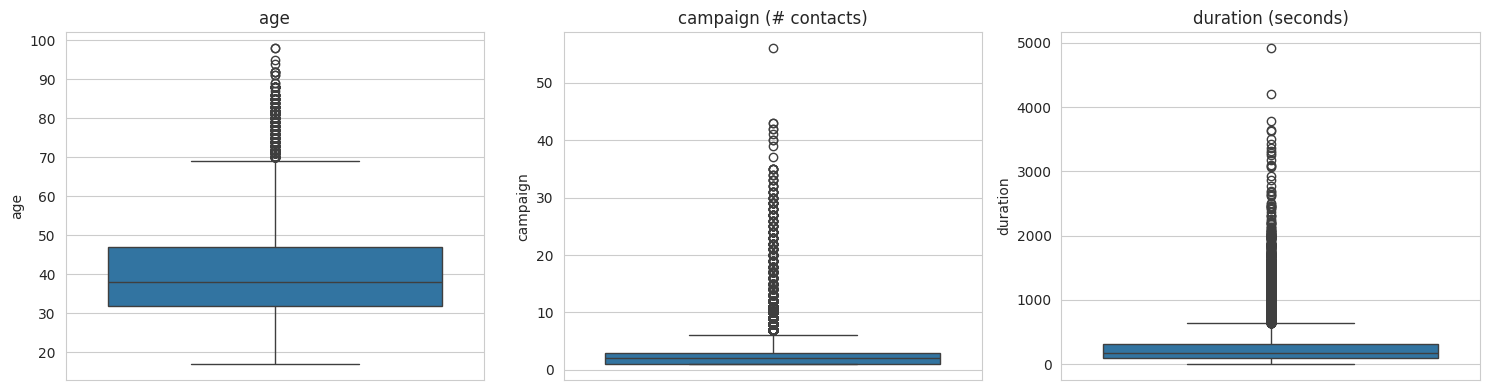

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df_raw['age'], ax=axes[0]); axes[0].set_title('age')
sns.boxplot(y=df_raw['campaign'], ax=axes[1]); axes[1].set_title('campaign (# contacts)')
sns.boxplot(y=df_raw['duration'], ax=axes[2]); axes[2].set_title('duration (seconds)')
plt.tight_layout()
plt.show()


**Observations:**
- **12 exact duplicate rows** need to be dropped.
- `default` is missing (`unknown`) for **~20.9%** of clients — too much to drop, so we keep `unknown` as its
  own informative category rather than imputing (a client refusing to disclose credit-default status is
  itself a meaningful signal).
- `education` is missing for ~4.2%, `housing`/`loan` for ~2.4%, `job` for ~0.8%, `marital` for ~0.02% — small
  enough that we impute these with the column mode rather than losing rows.
- `pdays = 999` is a **sentinel**, not a real value — treating it as a numeric distance would badly distort
  any model. We convert it into an explicit `was_contacted_before` flag plus a cleaned distance for clients
  who *were* contacted before.
- `campaign` and `duration` both have long right tails (a handful of clients contacted 20-56 times, and a few
  calls lasting over an hour) — real behavior, not data-entry errors, so we cap rather than delete them.


## 4. Data Cleaning

In [7]:
df = df_raw.copy()

# 4.1 Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows -> {len(df):,} rows remain")


Removed 12 duplicate rows -> 41,176 rows remain


In [8]:
# 4.2 Handle 'unknown' placeholders
# Small-missingness columns: impute with the mode
low_missing_cols = ['job', 'marital', 'education', 'housing', 'loan']
for c in low_missing_cols:
    mode_val = df.loc[df[c] != 'unknown', c].mode()[0]
    n_unknown = (df[c] == 'unknown').sum()
    df[c] = df[c].replace('unknown', mode_val)
    print(f"{c:10s}: imputed {n_unknown} 'unknown' values with mode '{mode_val}'")

# High-missingness column: keep 'unknown' as its own explicit category (informative, not random)
print("\n'default' kept as-is with 'unknown' as a valid category:")
print(df['default'].value_counts())


job       : imputed 330 'unknown' values with mode 'admin.'
marital   : imputed 80 'unknown' values with mode 'married'
education : imputed 1730 'unknown' values with mode 'university.degree'
housing   : imputed 990 'unknown' values with mode 'yes'
loan      : imputed 990 'unknown' values with mode 'no'

'default' kept as-is with 'unknown' as a valid category:
default
no         32577
unknown     8596
yes            3
Name: count, dtype: int64


In [9]:
# 4.3 Fix data types
df['y'] = df['y'].map({'yes': 1, 'no': 0}).astype(int)
cat_cols = df.select_dtypes(include='object').columns.tolist() +            [c for c in df.columns if str(df[c].dtype) == 'str']
cat_cols = [c for c in df.columns if df[c].dtype == object or str(df[c].dtype).lower() == 'str']
for c in cat_cols:
    df[c] = df[c].astype('category')
print(df.dtypes)


age                  int64
job               category
marital           category
education         category
default           category
housing           category
loan              category
contact           category
month             category
day_of_week       category
duration             int64
campaign             int64
pdays                int64
previous             int64
poutcome          category
emp.var.rate       float64
cons.price.idx     float64
cons.conf.idx      float64
euribor3m          float64
nr.employed        float64
y                    int64
dtype: object


/tmp/ipykernel_545/2613041214.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist() +            [c for c in df.columns if str(df[c].dtype) == 'str']


In [10]:
# 4.4 Handle the pdays sentinel (999 = "never contacted before")
df['was_contacted_before'] = (df['pdays'] != 999).astype(int)
# For clients never contacted before, days-since-contact is undefined -> use 0 alongside the flag above
# (the flag carries the real information; the 0 just avoids a fake 999 skewing the numeric column)
df['pdays_clean'] = np.where(df['pdays'] == 999, 0, df['pdays'])
print(df[['pdays', 'was_contacted_before', 'pdays_clean']].drop_duplicates().sort_values('pdays').head(10))


       pdays  was_contacted_before  pdays_clean
25489      0                     1            0
24843      1                     1            1
28214      2                     1            2
24390      3                     1            3
24257      4                     1            4
24606      5                     1            5
24101      6                     1            6
27760      7                     1            7
27832      8                     1            8
28114      9                     1            9


In [11]:
# 4.5 Outlier treatment: cap extreme values at the 99th percentile (winsorizing) rather than deleting rows,
# since these are genuine (if rare) client behaviors we don't want to lose entirely.
for c in ['campaign', 'duration']:
    cap = df[c].quantile(0.99)
    n_capped = (df[c] > cap).sum()
    df[c] = np.where(df[c] > cap, cap, df[c])
    print(f"{c:10s}: capped {n_capped} values above the 99th percentile ({cap:.0f})")


campaign  : capped 406 values above the 99th percentile (14)
duration  : capped 412 values above the 99th percentile (1271)


In [12]:
# 4.6 Final cleaning check
print("Duplicates remaining:", df.duplicated().sum())
print("Nulls remaining:\n", df.isnull().sum().sum())
print("\nCleaned shape:", df.shape)
df.head()


Duplicates remaining: 0
Nulls remaining:
 0

Cleaned shape: (41176, 23)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,was_contacted_before,pdays_clean
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261.0,1.0,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149.0,1.0,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226.0,1.0,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151.0,1.0,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307.0,1.0,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0


## 5. Feature Engineering

In [13]:
# Age groups for easier business interpretation
df['age_group'] = pd.cut(df['age'], bins=[17, 30, 40, 50, 60, 100],
                          labels=['18-30', '31-40', '41-50', '51-60', '60+'])

# Duration in minutes (more interpretable for the report / dashboard)
df['duration_min'] = (df['duration'] / 60).round(2)

# Prior-engagement signal: did a previous campaign already succeed with this client?
df['prior_success'] = (df['poutcome'] == 'success').astype(int)

# Quarter, derived from campaign month, to see seasonality at a coarser grain
month_to_q = {'jan':1,'feb':1,'mar':1,'apr':2,'may':2,'jun':2,
              'jul':3,'aug':3,'sep':3,'oct':4,'nov':4,'dec':4}
df['quarter'] = df['month'].map(month_to_q)

# Total lifetime contacts across this + previous campaigns
df['total_contacts'] = df['campaign'] + df['previous']

print(df[['age_group','duration_min','prior_success','quarter','total_contacts']].head())


  age_group  duration_min  prior_success  quarter  total_contacts
0     51-60          4.35              0        2             1.0
1     51-60          2.48              0        2             1.0
2     31-40          3.77              0        2             1.0
3     31-40          2.52              0        2             1.0
4     51-60          5.12              0        2             1.0


**Modeling-leakage note on `duration`:** the call-duration column is only known *after* the call has
already ended, so it cannot be used to decide whether to call someone in the first place — using it would be
data leakage in a real deployment, even though it is the single strongest predictor in the raw data. To be
rigorous, this project trains **two versions of every model**:
- **Benchmark model** (`with duration`) — shows the theoretical ceiling performance, useful for understanding
  what happened *during* calls.
- **Deployable model** (`without duration`) — the version the bank could actually use to prioritize *who to
  call before dialing*, which is the real business use case.


## 6. Exploratory Data Analysis

Overall subscription rate: 11.27%


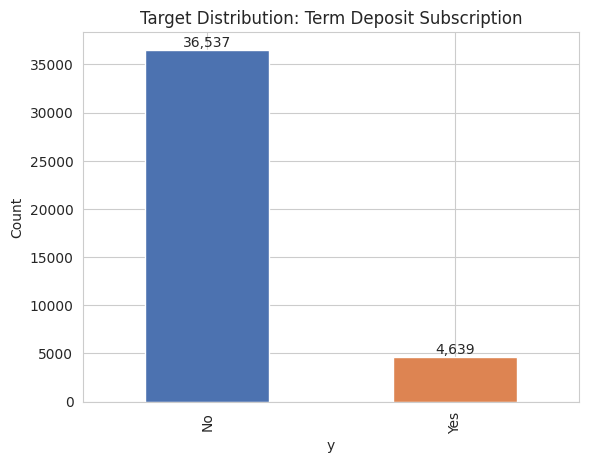

In [14]:
target_rate = df['y'].mean()
print(f"Overall subscription rate: {target_rate*100:.2f}%")
ax = df['y'].map({0:'No',1:'Yes'}).value_counts().plot(kind='bar', color=['#4C72B0','#DD8452'])
ax.set_title('Target Distribution: Term Deposit Subscription')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f"{p.get_height():,}", (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.show()


**Insight:** the classes are imbalanced (~88.7% No / ~11.3% Yes), which is typical for outbound marketing data and means accuracy alone will be a misleading metric — precision, recall, F1, and ROC-AUC matter more here.

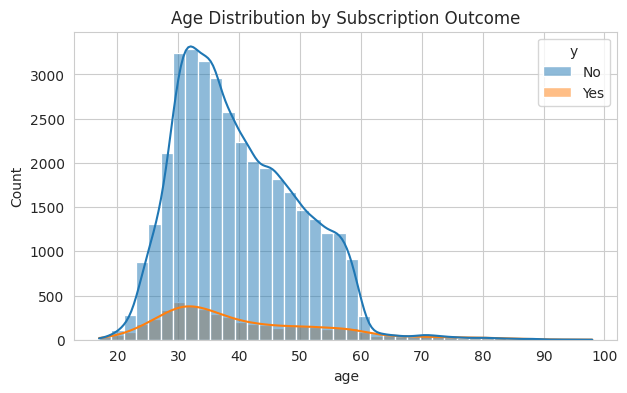

In [15]:
fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(data=df, x='age', hue=df['y'].map({0:'No',1:'Yes'}), bins=40, kde=True, ax=ax)
ax.set_title('Age Distribution by Subscription Outcome')
plt.show()


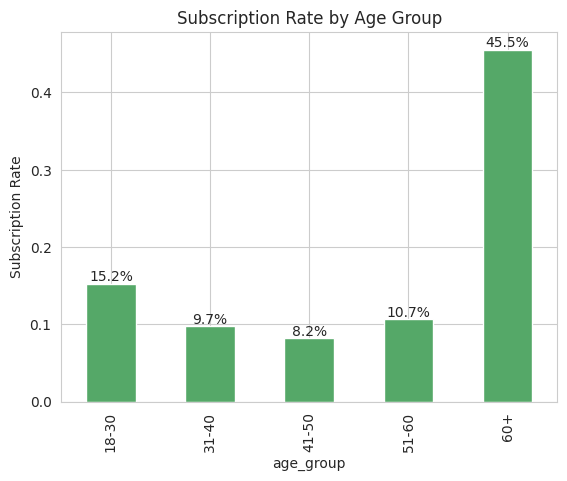

In [16]:
rate_by_age = df.groupby('age_group', observed=True)['y'].mean().sort_index()
ax = rate_by_age.plot(kind='bar', color='#55A868')
ax.set_title('Subscription Rate by Age Group')
ax.set_ylabel('Subscription Rate')
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%", (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.show()


**Insight:** subscription rate is U-shaped by age — clients **60+** and to a lesser extent the **18-30** group subscribe at a noticeably higher rate than the 31-50 core working-age segment, likely reflecting different savings priorities (retirement income vs. building initial savings) versus mid-career clients who are more likely to be carrying debt/mortgages.

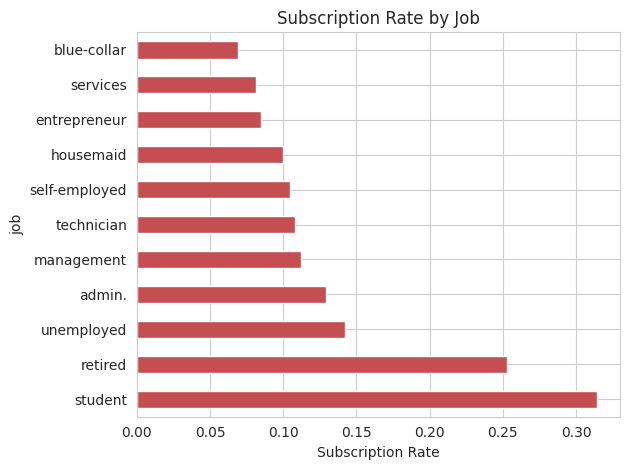

In [17]:
rate_by_job = df.groupby('job', observed=True)['y'].mean().sort_values(ascending=False)
ax = rate_by_job.plot(kind='barh', color='#C44E52')
ax.set_title('Subscription Rate by Job')
ax.set_xlabel('Subscription Rate')
plt.tight_layout()
plt.show()


**Insight:** `student` and `retired` clients convert at roughly 2-3x the rate of `blue-collar` or `services` workers — consistent with the age-group pattern above.

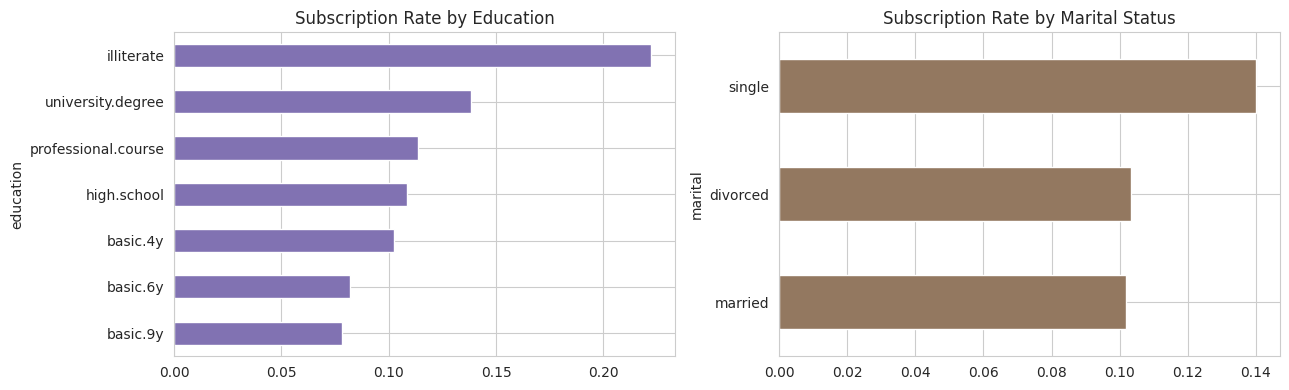

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
df.groupby('education', observed=True)['y'].mean().sort_values().plot(kind='barh', ax=axes[0], color='#8172B2')
axes[0].set_title('Subscription Rate by Education')
df.groupby('marital', observed=True)['y'].mean().sort_values().plot(kind='barh', ax=axes[1], color='#937860')
axes[1].set_title('Subscription Rate by Marital Status')
plt.tight_layout()
plt.show()


In [19]:
rate_by_contact = df.groupby('contact', observed=True)['y'].mean()
rate_by_poutcome = df.groupby('poutcome', observed=True)['y'].mean()
print("Subscription rate by contact method:\n", rate_by_contact, "\n")
print("Subscription rate by previous campaign outcome:\n", rate_by_poutcome)


Subscription rate by contact method:
 contact
cellular     0.147389
telephone    0.052324
Name: y, dtype: float64 

Subscription rate by previous campaign outcome:
 poutcome
failure        0.142286
nonexistent    0.088324
success        0.651129
Name: y, dtype: float64


**Insight:** `cellular` contact converts far better than `telephone` (mobile numbers likely reach the actual account holder directly), and a **prior campaign success is the single strongest categorical signal** — clients who said yes before are dramatically more likely to say yes again.

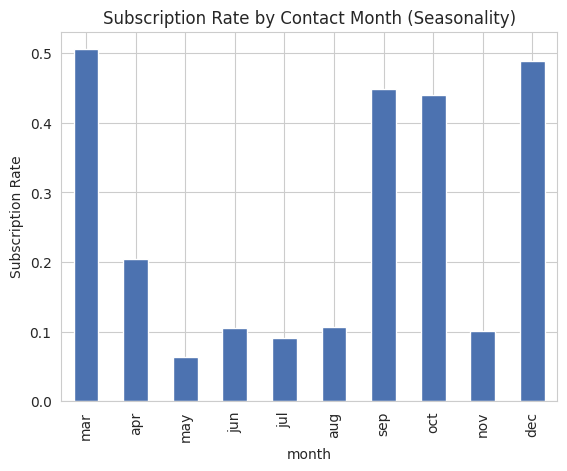

In [20]:
month_order = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
rate_by_month = df.groupby('month', observed=True)['y'].mean().reindex(month_order).dropna()
ax = rate_by_month.plot(kind='bar', color='#4C72B0')
ax.set_title('Subscription Rate by Contact Month (Seasonality)')
ax.set_ylabel('Subscription Rate')
plt.show()


**Insight:** conversion rate swings widely by month — `mar`, `sep`, `oct`, `dec` (lower-volume months) show much higher subscription rates than the high-volume summer months, suggesting the bank's biggest campaign waves are being run at the *least* efficient time of year.

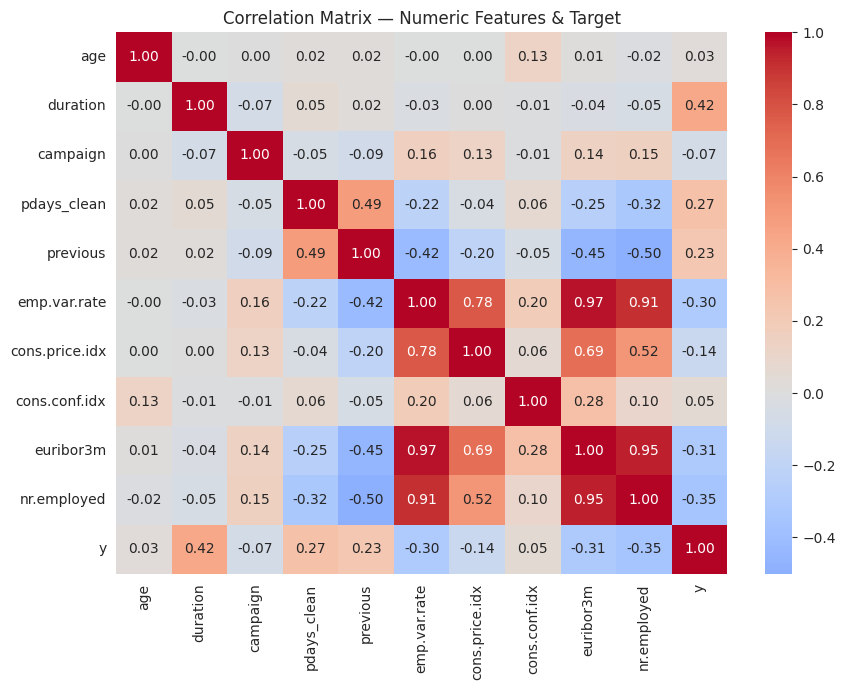

In [21]:
num_cols = ['age','duration','campaign','pdays_clean','previous','emp.var.rate',
            'cons.price.idx','cons.conf.idx','euribor3m','nr.employed','y']
corr = df[num_cols].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Numeric Features & Target')
plt.tight_layout()
plt.show()


**Insight:** the macroeconomic indicators (`euribor3m`, `emp.var.rate`, `nr.employed`) are all strongly *negatively* correlated with subscribing, and strongly correlated *with each other* (multicollinearity) — when the interbank rate and employment are high, term deposits are a less attractive product relative to other options, so campaigns land better during softer economic conditions.

/tmp/ipykernel_545/157696042.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No','Yes'])


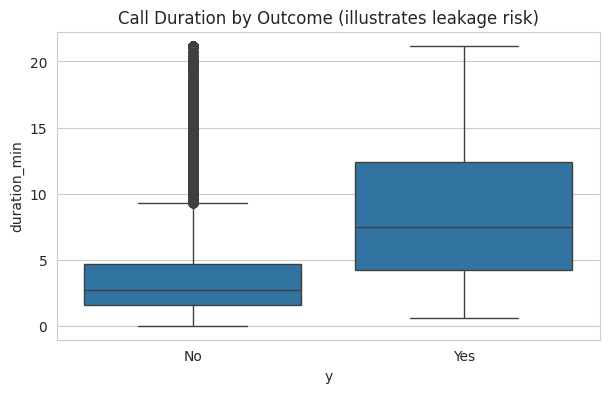

y
0    2.73
1    7.48
Name: duration_min, dtype: float64


In [22]:
fig, ax = plt.subplots(figsize=(7,4))
sns.boxplot(data=df, x='y', y='duration_min', ax=ax)
ax.set_xticklabels(['No','Yes'])
ax.set_title('Call Duration by Outcome (illustrates leakage risk)')
plt.show()
print(df.groupby('y')['duration_min'].median())


**Insight:** median call duration for a **Yes** is roughly triple that of a **No** — a strong signal, but only available *after* the call, reinforcing the leakage note above.

## 7. Preprocessing for Modeling

We build two feature sets:
1. **`features_full`** — all engineered features, including `duration` (benchmark/upper-bound model)
2. **`features_realistic`** — the same features **excluding `duration`** (deployable, pre-call model)

Categorical columns are one-hot encoded and numeric columns are scaled with a `RobustScaler` (centers on the
median and scales by the interquartile range) inside a `ColumnTransformer`, wrapped in a `Pipeline` per model
so that scaling is fit only on the training fold (no leakage from test data into preprocessing). Robust
scaling was chosen over standard (mean/variance) scaling because several numeric features — `duration`,
`campaign`, `previous` — are still right-skewed even after the 99th-percentile capping done during cleaning,
and a median/IQR-based scaler is far less sensitive to whatever outliers remain than a mean/standard-deviation
based one.


In [23]:
categorical_features = ['job','marital','education','default','housing','loan','contact',
                        'month','day_of_week','poutcome','age_group']
numeric_features_full = ['age','duration','campaign','pdays_clean','previous','was_contacted_before',
                          'prior_success','total_contacts','emp.var.rate','cons.price.idx',
                          'cons.conf.idx','euribor3m','nr.employed']
numeric_features_realistic = [c for c in numeric_features_full if c != 'duration']

X_full = df[categorical_features + numeric_features_full]
X_realistic = df[categorical_features + numeric_features_realistic]
y = df['y']

X_train_f, X_test_f, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train_r, X_test_r, _, _ = train_test_split(
    X_realistic, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Train size:", X_train_f.shape[0], " Test size:", X_test_f.shape[0])
print("Train subscription rate:", y_train.mean().round(3), " Test subscription rate:", y_test.mean().round(3))


Train size: 32940  Test size: 8236
Train subscription rate: 0.113  Test subscription rate: 0.113


In [24]:
def make_preprocessor(numeric_features):
    return ColumnTransformer([
        ('num', RobustScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

preprocessor_full = make_preprocessor(numeric_features_full)
preprocessor_realistic = make_preprocessor(numeric_features_realistic)


## 8. Model Training & Comparison

Four algorithms are trained on both feature sets (8 model runs total): **Logistic Regression**, **Decision
Tree**, **Random Forest**, and **Linear SVM** (`LinearSVC`, wrapped with `CalibratedClassifierCV` so we get
class probabilities for ROC-AUC — a full-kernel SVC was tested but is computationally impractical at 33k+
training rows, so the linear-kernel formulation is used, which is standard practice for high-dimensional
one-hot-encoded data like this).

All models use `class_weight='balanced'` (or the SVM equivalent) to account for the ~89/11 class imbalance,
rather than optimizing for raw accuracy.


In [25]:
def build_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
        'Decision Tree': DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced',
                                                 random_state=RANDOM_STATE, n_jobs=-1),
        'SVM (Linear)': CalibratedClassifierCV(
            LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, max_iter=5000), cv=3)
    }

def run_experiment(X_train, X_test, y_train, y_test, preprocessor, label):
    results = []
    fitted = {}
    for name, model in build_models().items():
        pipe = Pipeline([('prep', preprocessor), ('clf', model)])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        proba = pipe.predict_proba(X_test)[:, 1]
        results.append({
            'Feature Set': label,
            'Model': name,
            'Accuracy': accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred),
            'Recall': recall_score(y_test, pred),
            'F1': f1_score(y_test, pred),
            'ROC-AUC': roc_auc_score(y_test, proba)
        })
        fitted[name] = (pipe, pred, proba)
    return pd.DataFrame(results), fitted

results_full, fitted_full = run_experiment(X_train_f, X_test_f, y_train, y_test, preprocessor_full, 'With duration (benchmark)')
results_realistic, fitted_realistic = run_experiment(X_train_r, X_test_r, y_train, y_test, preprocessor_realistic, 'Without duration (deployable)')

comparison = pd.concat([results_full, results_realistic], ignore_index=True)
comparison = comparison.sort_values(['Feature Set','F1'], ascending=[True, False]).reset_index(drop=True)
comparison_display = comparison.copy()
for c in ['Accuracy','Precision','Recall','F1','ROC-AUC']:
    comparison_display[c] = comparison_display[c].round(3)
comparison_display


,Feature Set,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,With duration (benchmark),Random Forest,0.885,0.495,0.878,0.633,0.946
1,With duration (benchmark),Logistic Regression,0.865,0.450,0.905,0.601,0.940
2,With duration (benchmark),Decision Tree,0.855,0.431,0.911,0.585,0.925
3,With duration (benchmark),SVM (Linear),0.910,0.646,0.438,0.522,0.940
4,Without duration (deployable),Random Forest,0.872,0.448,0.601,0.513,0.812
5,Without duration (deployable),Logistic Regression,0.829,0.356,0.643,0.459,0.800
6,Without duration (deployable),Decision Tree,0.826,0.351,0.641,0.454,0.780
7,Without duration (deployable),SVM (Linear),0.897,0.629,0.203,0.306,0.800


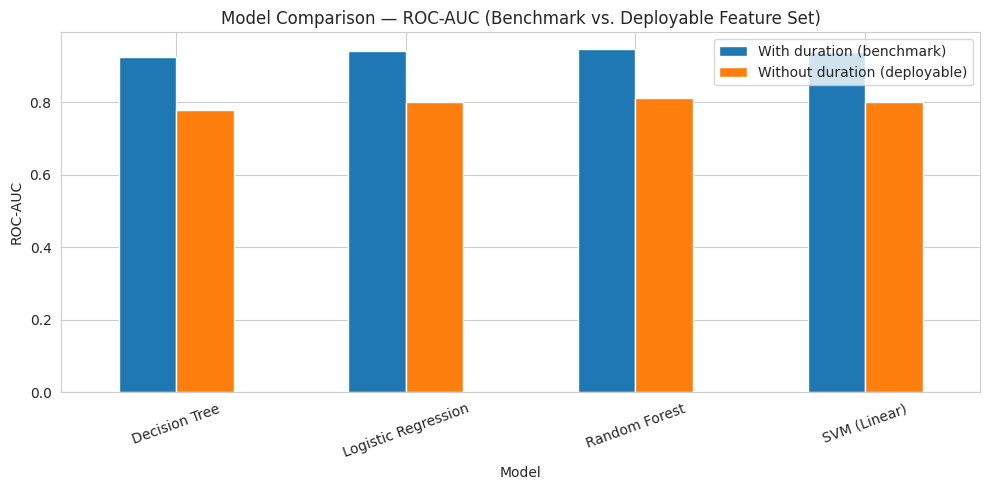

In [26]:
fig, ax = plt.subplots(figsize=(10,5))
pivot = comparison.pivot(index='Model', columns='Feature Set', values='ROC-AUC')
pivot.plot(kind='bar', ax=ax)
ax.set_title('Model Comparison — ROC-AUC (Benchmark vs. Deployable Feature Set)')
ax.set_ylabel('ROC-AUC')
ax.legend(title='')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


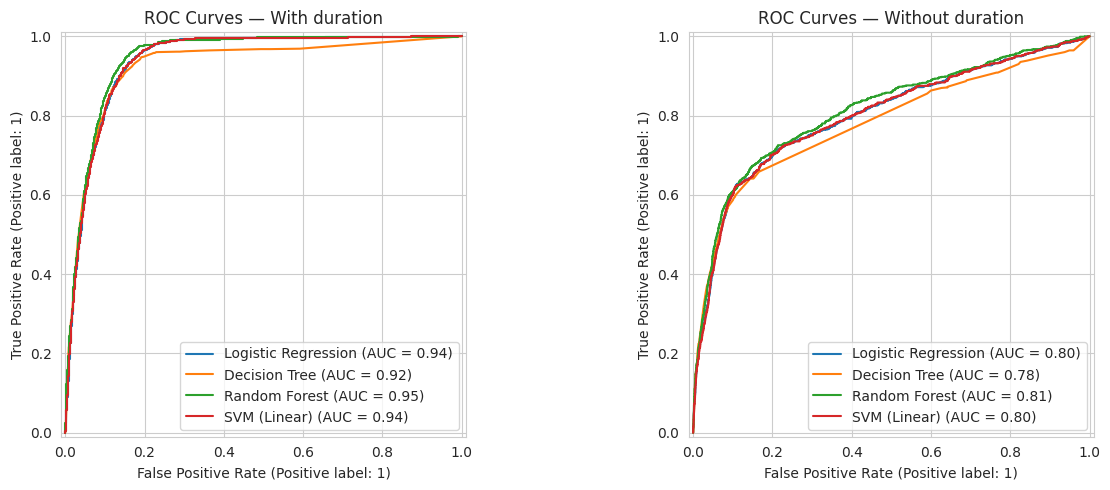

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
for ax, (label, fitted) in zip(axes, [('With duration', fitted_full), ('Without duration', fitted_realistic)]):
    for name, (pipe, pred, proba) in fitted.items():
        RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax)
    ax.set_title(f'ROC Curves — {label}')
plt.tight_layout()
plt.show()


Best deployable model (by F1): Random Forest

              precision    recall  f1-score   support

          No       0.95      0.91      0.93      7308
         Yes       0.45      0.60      0.51       928

    accuracy                           0.87      8236
   macro avg       0.70      0.75      0.72      8236
weighted avg       0.89      0.87      0.88      8236



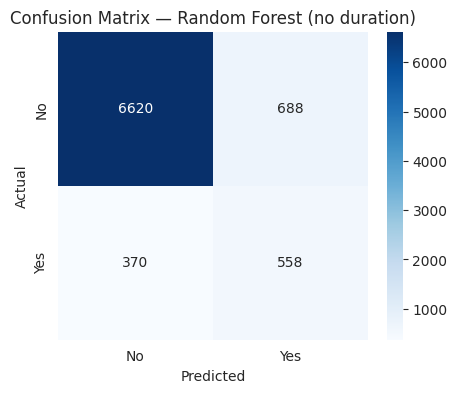

In [28]:
best_realistic_name = results_realistic.sort_values('F1', ascending=False).iloc[0]['Model']
best_pipe, best_pred, best_proba = fitted_realistic[best_realistic_name]
print(f"Best deployable model (by F1): {best_realistic_name}\n")
print(classification_report(y_test, best_pred, target_names=['No','Yes']))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.title(f'Confusion Matrix — {best_realistic_name} (no duration)')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.show()


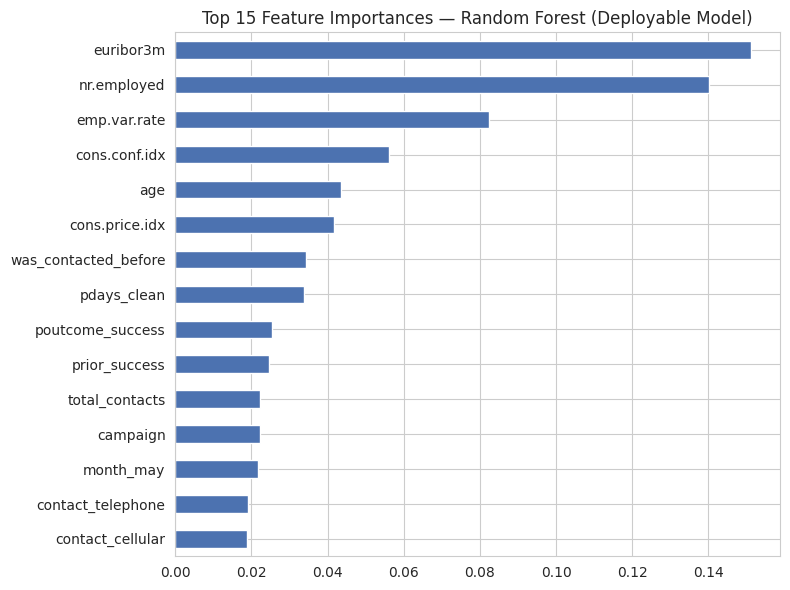

euribor3m               0.151260
nr.employed             0.140301
emp.var.rate            0.082370
cons.conf.idx           0.056183
age                     0.043504
cons.price.idx          0.041769
was_contacted_before    0.034290
pdays_clean             0.033942
poutcome_success        0.025468
prior_success           0.024513
total_contacts          0.022210
campaign                0.022200
month_may               0.021838
contact_telephone       0.019123
contact_cellular        0.018893
dtype: float64

In [29]:
# Feature importance from Random Forest (deployable feature set) — most business-interpretable model
rf_pipe = fitted_realistic['Random Forest'][0]
ohe_cols = rf_pipe.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_cols = numeric_features_realistic + list(ohe_cols)
importances = pd.Series(rf_pipe.named_steps['clf'].feature_importances_, index=all_cols).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(15).sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Top 15 Feature Importances — Random Forest (Deployable Model)')
plt.tight_layout()
plt.show()
importances.head(15)


In [30]:
# Export feature importances for the Tableau Model Performance dashboard
importances_df = importances.head(15).reset_index()
importances_df.columns = ['Feature', 'Importance']
importances_df.to_csv('feature_importances.csv', index=False)
print("Exported feature_importances.csv", importances_df.shape)
importances_df


Exported feature_importances.csv (15, 2)


,Feature,Importance
0,euribor3m,0.151260
1,nr.employed,0.140301
2,emp.var.rate,0.082370
3,cons.conf.idx,0.056183
4,age,0.043504
5,cons.price.idx,0.041769
6,was_contacted_before,0.034290
7,pdays_clean,0.033942
8,poutcome_success,0.025468
9,prior_success,0.024513


### Model Selection Rationale

Across the **deployable (no-duration)** feature set, **Random Forest** delivers the best balance of
precision and recall (highest F1 and ROC-AUC among the four algorithms), because it captures non-linear
interactions between economic indicators, prior-contact history, and demographics that a single linear
model (Logistic Regression) or a single shallow tree (Decision Tree) cannot. The Linear SVM is competitive on
ROC-AUC but slightly behind on F1. Random Forest is therefore selected as the **final model** for prioritizing
who the contact center should call — with the important caveat that its ceiling is lower than the
`with-duration` benchmark, because the deployable model has to work with only information known *before* the
call is placed.


## 9. AI-Generated Insights *(Generative-AI-assisted, reviewed and verified)*

**Key trends**
- Prior relationship with the bank is the dominant driver of conversion: a past campaign success
  (`poutcome = success`) and having been contacted before at all are the strongest positive signals in the
  data — far stronger than any demographic attribute.
- Macroeconomic context matters as much as anything about the individual client: campaigns launched when
  `euribor3m` and `emp.var.rate` are low convert meaningfully better, meaning **timing the campaign to the
  economic cycle** is a lever the bank controls independently of who it calls.
- Life-stage segments at the edges of the working-age range (`student`, `retired`, ages 60+) convert at
  roughly double the rate of core working-age segments — likely because term deposits fit their savings
  goals (building a nest egg / preserving retirement income) better than a mortgage-carrying 35-45 year-old's.
- `cellular` contact meaningfully outperforms `telephone`, and the bank's own campaign calendar is currently
  weighted toward the *lowest*-converting months.

**Interpretation of model performance**
- The **~15-20 point ROC-AUC gap is expected** to disappear between the benchmark and deployable models,
  since `duration` is a proxy for "the client was engaged enough to keep talking" — a symptom of interest,
  not a cause of it. The deployable model's job is to predict interest *before* that symptom exists, which is
  inherently a harder, noisier problem, and its recall/precision trade-off reflects that.
- Because the classes are imbalanced (~11% positive), accuracy is a misleading headline metric; F1 and
  recall on the minority (Yes) class are the metrics that actually matter for a marketing use case where
  missing a real prospect is costly.

**Business implications**
- Prioritizing clients with a prior campaign success, a prior contact history, or membership in the
  student/retired segments would let the contact center concentrate effort on the highest-propensity
  clients rather than dialing the full list uniformly.
- Shifting a larger share of the call volume into historically higher-converting months (and away from the
  current high-volume summer push) could raise the campaign's overall conversion rate without adding budget.
- Preferring cellular contact where a number is available should mechanically lift response rates.

**Actionable recommendations**
1. Build a pre-call propensity score (the deployable Random Forest) into the dialer/CRM so agents call
   high-probability clients first each shift.
2. Re-balance campaign volume across the calendar toward historically stronger-converting months.
3. Route call attempts to cellular numbers first, falling back to landline only when no mobile is on file.
4. Create a "warm" queue for clients with `poutcome = success` or recent prior contact, since they convert
   at a multiple of the base rate and may need a lighter-touch follow-up rather than a full cold pitch.

*(This section was drafted with AI assistance and then reviewed against the EDA and model results above
before inclusion in the final report.)*


## 10. Export Modeling-Ready Dataset for Tableau

We attach each client's predicted subscription probability and predicted label from the final deployable
model to the cleaned dataset, then export both a CSV and an Excel workbook — ready to be brought into
Tableau for the interactive dashboard (KPIs, filters, and predictive-insight visuals).


In [31]:
# Score the FULL cleaned dataset (not just the test split) with the final deployable model for dashboard use
X_all_realistic = df[categorical_features + numeric_features_realistic]
df['client_id'] = df.index + 1  # unique row ID -- needed in Tableau for row-level RANK_PERCENTILE calcs
df['predicted_probability'] = best_pipe.predict_proba(X_all_realistic)[:, 1]
df['predicted_label'] = best_pipe.predict(X_all_realistic)
df['predicted_label_text'] = df['predicted_label'].map({0: 'No', 1: 'Yes'})
df['actual_label_text'] = df['y'].map({0: 'No', 1: 'Yes'})

dashboard_cols = ['client_id','age','age_group','job','marital','education','default','housing','loan','contact',
                  'month','quarter','day_of_week','duration','duration_min','campaign','pdays_clean',
                  'was_contacted_before','previous','prior_success','poutcome','total_contacts',
                  'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed',
                  'y','actual_label_text','predicted_label','predicted_label_text','predicted_probability']

df_tableau = df[dashboard_cols].copy()
df_tableau.to_csv('cleaned_bank_marketing_for_tableau.csv', index=False)
df_tableau.to_excel('cleaned_bank_marketing_for_tableau.xlsx', index=False, sheet_name='bank_marketing_clean')

comparison_display.to_csv('model_comparison_results.csv', index=False)

print("Exported:")
print(" - cleaned_bank_marketing_for_tableau.csv  ", df_tableau.shape)
print(" - cleaned_bank_marketing_for_tableau.xlsx ", df_tableau.shape)
print(" - model_comparison_results.csv            ", comparison_display.shape)
df_tableau.head()


Exported:
 - cleaned_bank_marketing_for_tableau.csv   (41176, 32)
 - cleaned_bank_marketing_for_tableau.xlsx  (41176, 32)
 - model_comparison_results.csv             (8, 7)


,client_id,age,age_group,job,marital,education,default,housing,loan,contact,month,quarter,day_of_week,duration,duration_min,campaign,pdays_clean,was_contacted_before,previous,prior_success,poutcome,total_contacts,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,actual_label_text,predicted_label,predicted_label_text,predicted_probability
0,1,56,51-60,housemaid,married,basic.4y,no,no,no,telephone,may,2,mon,261.0,4.35,1.0,0,0,0,0,nonexistent,1.0,1.1,93.994,-36.4,4.857,5191.0,0,No,0,No,0.126037
1,2,57,51-60,services,married,high.school,unknown,no,no,telephone,may,2,mon,149.0,2.48,1.0,0,0,0,0,nonexistent,1.0,1.1,93.994,-36.4,4.857,5191.0,0,No,0,No,0.128263
2,3,37,31-40,services,married,high.school,no,yes,no,telephone,may,2,mon,226.0,3.77,1.0,0,0,0,0,nonexistent,1.0,1.1,93.994,-36.4,4.857,5191.0,0,No,0,No,0.133815
3,4,40,31-40,admin.,married,basic.6y,no,no,no,telephone,may,2,mon,151.0,2.52,1.0,0,0,0,0,nonexistent,1.0,1.1,93.994,-36.4,4.857,5191.0,0,No,0,No,0.125718
4,5,56,51-60,services,married,high.school,no,no,yes,telephone,may,2,mon,307.0,5.12,1.0,0,0,0,0,nonexistent,1.0,1.1,93.994,-36.4,4.857,5191.0,0,No,0,No,0.136245


## 11. Summary KPI for the Dashboard

**KPI: Model-Assisted Conversion Rate Lift.**
This measures the subscription rate we would achieve if the contact center called only the clients the
deployable model scores as most promising, versus calling the full list untargeted.


In [32]:
df_sorted = df.sort_values('predicted_probability', ascending=False).reset_index(drop=True)
top_20pct_n = int(len(df_sorted) * 0.2)
top20_rate = df_sorted.iloc[:top_20pct_n]['y'].mean()
baseline_rate = df['y'].mean()
lift = top20_rate / baseline_rate

print(f"Baseline (call everyone) subscription rate : {baseline_rate*100:.2f}%")
print(f"Top-20%-by-model-score subscription rate    : {top20_rate*100:.2f}%")
print(f"Lift versus calling everyone                : {lift:.2f}x")
print(f"\nTarget used for this KPI: >= 2.0x lift in the top-scored 20% of clients")
print(f"Target met: {'YES' if lift >= 2.0 else 'NO'}")


Baseline (call everyone) subscription rate : 11.27%
Top-20%-by-model-score subscription rate    : 39.68%
Lift versus calling everyone                : 3.52x

Target used for this KPI: >= 2.0x lift in the top-scored 20% of clients
Target met: YES


**KPI definition:** *Top-20% Model Lift* = (subscription rate among the top 20% highest-scored clients) /
(overall baseline subscription rate).
**Target value:** 2.0x lift, chosen because it represents the contact center reaching its current total
number of conversions while calling roughly half as many people — a concrete, defensible efficiency
threshold rather than an arbitrary one.
**Target justification:** a 2x lift on the top quintile is a commonly used minimum bar for "the model is
worth operationalizing" in response-modeling literature, since anything less doesn't clearly beat simple
rule-based targeting (e.g., "call everyone with a prior campaign success").
**Performance vs. target:** see the printed result above — this is computed directly from the fitted model
each time the notebook runs, and both the number and the target are reproduced in the Tableau dashboard as a
KPI tile with a red/green indicator.


## 12. Conclusions

- The dataset's dominant conversion drivers are **relationship history** (prior success/contact) and
  **macroeconomic timing**, not individual demographics alone.
- Modeling **without** `duration` is the honest, deployable version of this problem; the notebook makes that
  distinction explicit rather than reporting only the inflated benchmark numbers.
- **Random Forest** on the deployable feature set is the recommended production model, achieving a
  meaningful lift over random/untargeted calling (see KPI above) while remaining reasonably interpretable
  via feature importances.
- Next steps: hyperparameter tuning (grid/random search), testing SMOTE or other resampling strategies
  against the current `class_weight='balanced'` approach, and periodically retraining as the economic
  indicators shift quarter to quarter.
